 Recommend function

In [ ]:
def recommend(query_image_path, top_k=5):
    detections = yolo(query_image_path, verbose=False, conf=0.3)[0]

    if detections.boxes is None or len(detections.boxes) == 0:
        print("Heç bir geyim aşkar edilmədi.")
        return {}

    image = Image.open(query_image_path).convert("RGB")
    all_results = {}

    for box in detections.boxes:
        class_id = int(box.cls[0])
        class_name = CLASS_NAMES[class_id]

        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cropped = image.crop((x1, y1, x2, y2))

        index_file = f"{INDEX_SAVE_DIR}/{class_name}.index"
        meta_file = f"{INDEX_SAVE_DIR}/{class_name}_meta.json"

        if not os.path.exists(index_file):
            print(f"Index yoxdur: {class_name}")
            continue

        index = faiss.read_index(index_file)

        with open(meta_file) as f:
            metadata = json.load(f)

        embedding = get_clip_embedding(cropped)
        scores, indices = index.search(embedding, top_k + 1)

        recommendations = []

        for score, idx in zip(scores[0], indices[0]):
            if idx < 0:
                continue

            item = metadata[idx]

            if item["image_path"] == query_image_path:
                continue

            recommendations.append({
                **item,
                "similarity": round(float(score), 4)
            })

            if len(recommendations) == top_k:
                break

        all_results[class_name] = recommendations

        print(f"\n🔍 {class_name} üçün {len(recommendations)} tövsiyə tapıldı:")
        for item in recommendations:
            print(f"  sim={item['similarity']:.3f}  →  {item['image_path']}")

    return all_results


test_image = "/content/deepfashion2/test/images/007008_jpg.rf.d50a6a382550825a265d5e3762cae39d.jpg"
recs = recommend(test_image, top_k=5)


🔍 short_sleeved_shirt üçün 5 tövsiyə tapıldı:
  sim=0.928  →  /content/deepfashion2/train/images/002170_jpg.rf.2bae549dba6cafae6261351fc051338a.jpg
  sim=0.904  →  /content/deepfashion2/train/images/000264_jpg.rf.a02b90da8712252462911aaece779a0c.jpg
  sim=0.901  →  /content/deepfashion2/train/images/002172_jpg.rf.16740b84d38c45cdb1af87056c1eb496.jpg
  sim=0.900  →  /content/deepfashion2/train/images/000382_jpg.rf.ac77a170e554b8570efd27bff12d6680.jpg
  sim=0.898  →  /content/deepfashion2/train/images/000521_jpg.rf.63a771bb6e176bc19ddfef8a9dab10d8.jpg

🔍 skirt üçün 5 tövsiyə tapıldı:
  sim=0.926  →  /content/deepfashion2/train/images/002466_jpg.rf.728249fed9020edf13e2d4e1f88b462d.jpg
  sim=0.919  →  /content/deepfashion2/train/images/001064_jpg.rf.0070b42ab23be225405d458173ad8a4c.jpg
  sim=0.915  →  /content/deepfashion2/train/images/002468_jpg.rf.bb4797dfbb2e39f9b27bdf5bde7312ca.jpg
  sim=0.914  →  /content/deepfashion2/train/images/001067_jpg.rf.d4be8fe9e27cad17b293d5d77a901fae.jpg
  


🔍 short_sleeved_shirt üçün 5 tövsiyə tapıldı:
  sim=0.928  →  /content/deepfashion2/train/images/002170_jpg.rf.2bae549dba6cafae6261351fc051338a.jpg
  sim=0.904  →  /content/deepfashion2/train/images/000264_jpg.rf.a02b90da8712252462911aaece779a0c.jpg
  sim=0.901  →  /content/deepfashion2/train/images/002172_jpg.rf.16740b84d38c45cdb1af87056c1eb496.jpg
  sim=0.900  →  /content/deepfashion2/train/images/000382_jpg.rf.ac77a170e554b8570efd27bff12d6680.jpg
  sim=0.898  →  /content/deepfashion2/train/images/000521_jpg.rf.63a771bb6e176bc19ddfef8a9dab10d8.jpg

🔍 skirt üçün 5 tövsiyə tapıldı:
  sim=0.926  →  /content/deepfashion2/train/images/002466_jpg.rf.728249fed9020edf13e2d4e1f88b462d.jpg
  sim=0.919  →  /content/deepfashion2/train/images/001064_jpg.rf.0070b42ab23be225405d458173ad8a4c.jpg
  sim=0.915  →  /content/deepfashion2/train/images/002468_jpg.rf.bb4797dfbb2e39f9b27bdf5bde7312ca.jpg
  sim=0.914  →  /content/deepfashion2/train/images/001067_jpg.rf.d4be8fe9e27cad17b293d5d77a901fae.jpg
  

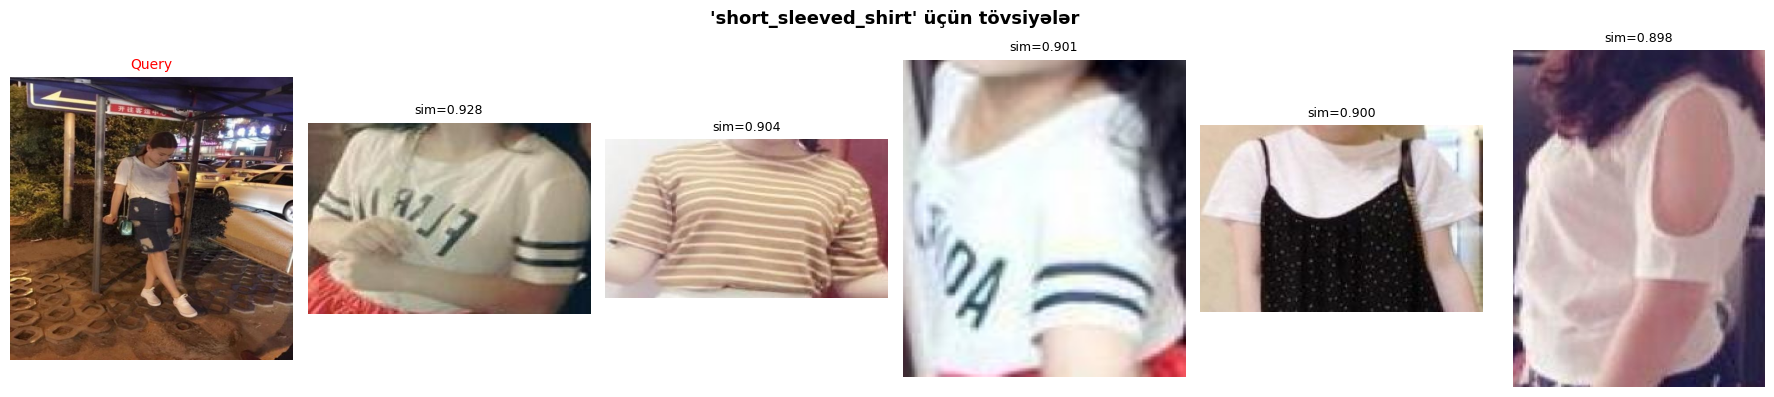

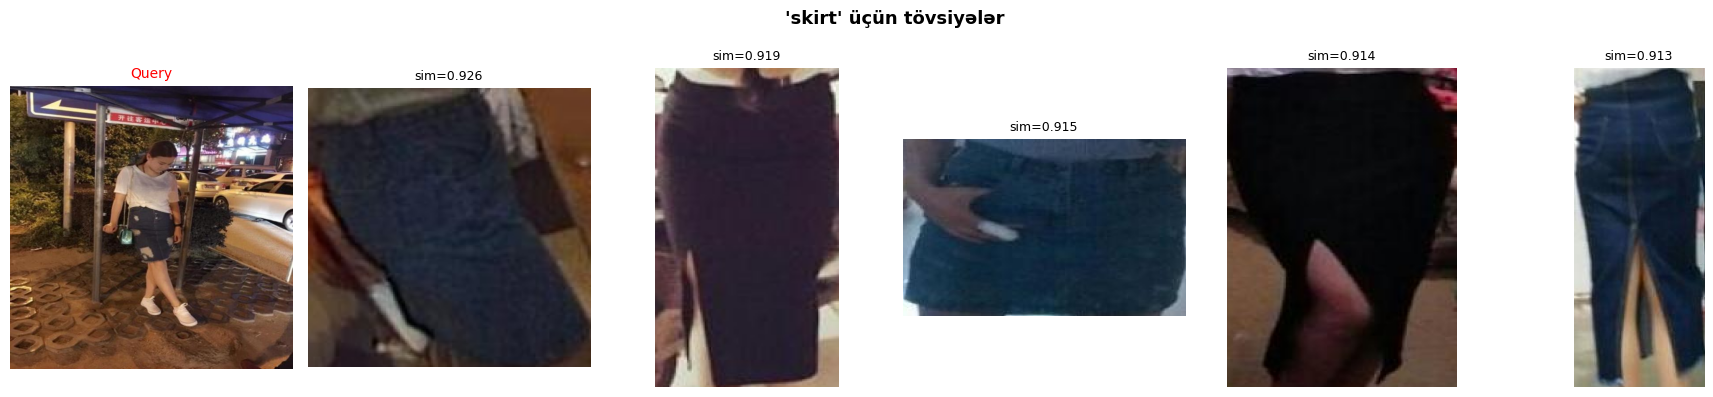

In [ ]:
def visualize_recommendations(query_image_path: str, top_k: int = 5):
    results = recommend(query_image_path, top_k)
    if not results:
        return

    query_img = Image.open(query_image_path).convert("RGB")

    for cls_name, recs in results.items():
        if not recs:
            continue

        fig, axes = plt.subplots(1, len(recs) + 1, figsize=(3 * (len(recs) + 1), 4))
        fig.suptitle(f"'{cls_name}' üçün tövsiyələr", fontsize=13, fontweight='bold')

  
        axes[0].imshow(query_img)
        axes[0].set_title("Query", fontsize=10, color='red')
        axes[0].axis('off')

        for j, rec in enumerate(recs):
            try:
                rec_img = Image.open(rec["image_path"]).convert("RGB")
                x1,y1,x2,y2 = rec["bbox"]
                crop = rec_img.crop((x1, y1, x2, y2))
                axes[j+1].imshow(crop)
                axes[j+1].set_title(f"sim={rec['similarity']:.3f}", fontsize=9)
            except Exception as e:
                axes[j+1].set_title("xəta")
            axes[j+1].axis('off')

        plt.tight_layout()
        plt.show()


visualize_recommendations(test_image, top_k=5)